In [45]:
import teehr
import pandas as pd
from teehr.evaluation.spark_session_utils import create_spark_session

from teehr import DeterministicMetrics as dm
from teehr import Signatures as s
from teehr import RowLevelCalculatedFields as rcf
from teehr import TimeseriesAwareCalculatedFields as tcf
from teehr import Bootstrappers as bs

from teehr.models.filters import TableFilter

from pyspark.sql import functions as F
from pyspark.sql import DataFrame
from pyspark.sql.types import DoubleType, FloatType
from functools import reduce

import matplotlib.pyplot as plt

import copy
import time

teehr.__version__

'0.6.5'

# Summary
This notebook is intended to identify and analyze inf and -inf values generated by the NWM diagnostics data processing workflow. Initial processing runs seem to indicate that relative_median_boot_0_05 and relative_minimum_boot_0_05 are the main fields computing as inf. This appears to be due to the prominence of "0" flow values in the observed data for the given locations in the given time window.

### Usage
Run the workbook.  Adjust the ROW_INDEX to view data for another location.  Adjust as needed to perform other analytics.

In [2]:
spark = create_spark_session()

INFO:teehr.evaluation.spark_session_utils:🚀 Creating Spark session: TEEHR Evaluation
INFO:teehr.evaluation.spark_session_utils:✅ Spark local configuration successful!
INFO:teehr.evaluation.spark_session_utils:Setting Hadoop's default AWS credentials provider and AWS region
INFO:teehr.evaluation.spark_session_utils:🔑 Using AWS session token from boto3
INFO:teehr.evaluation.spark_session_utils:Configuring Iceberg catalogs...
INFO:teehr.evaluation.spark_session_utils:⚙️ All settings applied. Creating Spark session...
INFO:teehr.evaluation.spark_session_utils:🎉 Spark session created successfully!


In [3]:
ev = teehr.RemoteReadOnlyEvaluation(spark=spark, enable_spark_proxy=True)

INFO:teehr.evaluation.evaluation:Using provided Spark session.
INFO:teehr.evaluation.evaluation:Active catalog set to iceberg.


In [5]:
table = ev.table("nwmd_metrics_by_location")
df = table.to_sdf()

INFO:teehr.evaluation.tables.generic_table:Getting table: nwmd_metrics_by_location.
INFO:teehr.evaluation.tables.base_table:Initializing Table for table: nwmd_metrics_by_location.
INFO:teehr.evaluation.tables.base_table:Loading files from iceberg.teehr.nwmd_metrics_by_location.
INFO:teehr.evaluation.read:Reading files from iceberg.teehr.nwmd_metrics_by_location.


In [46]:
numeric_cols = [
    field.name
    for field in df.schema.fields
    if isinstance(field.dataType, (DoubleType, FloatType))
]

condition = reduce(
    lambda a, b: a | b,
    [
        (F.col(c) == float("inf")) |
        (F.col(c) == float("-inf"))
        for c in numeric_cols
    ]
)

inf_rows = df.filter(condition)

inf_rows.show(truncate=False)

+-------------------+---------------------+------------------+---------+----------------------+------+-------+----------------------+---------+----------+-----+-------------------+-------+-------------------+-------------------+-------------------+----------------+-------------------+---------------------------+--------------------+-------------------------+----------------------+--------------------+-----------------------+-----------------------+-------------------------+-------------------------+--------------------------+--------------------------+--------------------------+--------------------------+-------------------------------------+-------------------------------------+-----------------------------------+-----------------------------------+-----------------------+-----------------------+-----------------------------+-----------------------------+--------------------------------+--------------------------------+----------------------------------------------+-------------------

In [7]:
from pyspark.sql import functions as F

for c in numeric_cols:
    n = df.filter(
        (F.col(c) == float("inf")) |
        (F.col(c) == float("-inf"))
    ).count()

    if n:
        print(f"{c}: {n} infinite values")

relative_median_boot_0_05: 65 infinite values
relative_minimum_boot_0_05: 207 infinite values


In [44]:
joined = ev.table("fcst_joined_timeseries").to_sdf()

INFO:teehr.evaluation.tables.generic_table:Getting table: fcst_joined_timeseries.
INFO:teehr.evaluation.tables.base_table:Initializing Table for table: fcst_joined_timeseries.
INFO:teehr.evaluation.tables.base_table:Loading files from iceberg.teehr.fcst_joined_timeseries.
INFO:teehr.evaluation.read:Reading files from iceberg.teehr.fcst_joined_timeseries.


In [55]:
ROW_INDEX = 2

row = inf_rows.toPandas().iloc[ROW_INDEX]

print(f"Location: {row['name']}")
print(f"Primary ID: {row['primary_location_id']}")
print(f"Secondary ID: {row['secondary_location_id']}")

ts = joined.filter(
    (F.col("primary_location_id") == row['primary_location_id']) &
    (F.col("secondary_location_id") == row['secondary_location_id']) &
    (F.col("configuration_name") == "nwm30_medium_range") &
    (F.col("variable_name") == "streamflow_hourly_inst") & 
    (F.col("value_time") >= "2026-01-01T00:00") &
    (F.col("value_time") <= "2026-03-31T23:59")
)

Location: River Des Peres at Macklind Ave, St Louis, MO
Primary ID: usgs-07010038
Secondary ID: nwm30-3624349


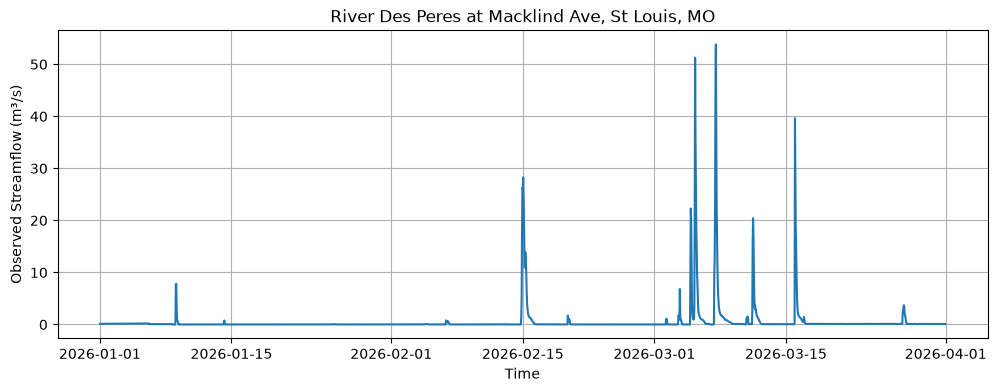

In [56]:
obs = (
    ts
    .select("value_time", "primary_value")
    .orderBy("value_time")
    .toPandas()
)

plt.figure(figsize=(12, 4))
plt.plot(obs["value_time"], obs["primary_value"])
plt.xlabel("Time")
plt.ylabel("Observed Streamflow (m³/s)")
plt.title(row['name'])
plt.grid(True)
plt.show()

In [54]:
ts.sort("primary_value").select("value_time", "primary_value", "secondary_value").show(10, truncate=False)

+-------------------+-------------+---------------+
|value_time         |primary_value|secondary_value|
+-------------------+-------------+---------------+
|2026-01-18 04:00:00|0.0          |0.049999997    |
|2026-01-18 04:00:00|0.0          |0.049999997    |
|2026-01-18 17:00:00|0.0          |0.049999997    |
|2026-01-18 04:00:00|0.0          |0.049999997    |
|2026-01-18 18:00:00|0.0          |0.049999997    |
|2026-01-18 17:00:00|0.0          |0.049999997    |
|2026-01-18 04:00:00|0.0          |0.049999997    |
|2026-01-18 18:00:00|0.0          |0.049999997    |
|2026-01-18 04:00:00|0.0          |0.049999997    |
|2026-01-18 04:00:00|0.0          |0.049999997    |
+-------------------+-------------+---------------+
only showing top 10 rows
